['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_api', '_json', 'author', 'contributors', 'coordinates', 'created_at', 'destroy', 'entities', 'favorite', 'favorite_count', 'favorited', 'geo', 'id', 'id_str', 'in_reply_to_screen_name', 'in_reply_to_status_id', 'in_reply_to_status_id_str', 'in_reply_to_user_id', 'in_reply_to_user_id_str', 'is_quote_status', 'lang', 'parse', 'parse_list', 'place', 'possibly_sensitive', 'quoted_status', 'quoted_status_id', 'quoted_status_id_str', 'retweet', 'retweet_count', 'retweeted', 'retweets', 'source', 'source_url', 'text', 'truncated', 'user']
50
132.2
9786
1436
                                              tweets                   id  \
0  

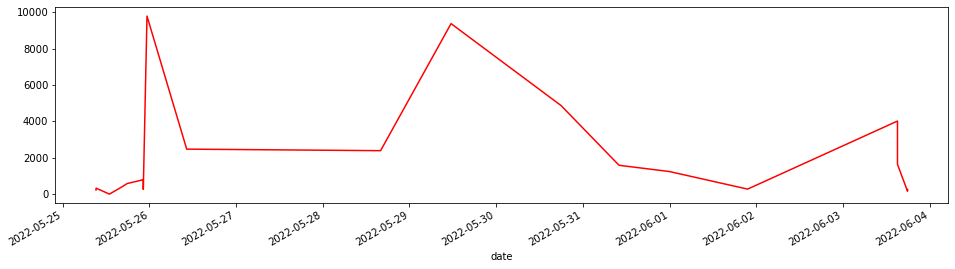

/tmp/ipykernel_20331/3739204534.py:149: MatplotlibDeprecationWarning: 
The 'quality' parameter of print_jpg() was deprecated in Matplotlib 3.3 and will be removed two minor releases later. Use pil_kwargs={'quality': ...} instead. If any parameter follows 'quality', they should be passed as keyword, not positionally.
  plt.savefig('Visuallikes.jpg',dpi=800, quality=90, optimize=True, progressive=True)
/tmp/ipykernel_20331/3739204534.py:149: MatplotlibDeprecationWarning: 
The 'optimize' parameter of print_jpg() was deprecated in Matplotlib 3.3 and will be removed two minor releases later. Use pil_kwargs={'optimize': ...} instead. If any parameter follows 'optimize', they should be passed as keyword, not positionally.
  plt.savefig('Visuallikes.jpg',dpi=800, quality=90, optimize=True, progressive=True)
/tmp/ipykernel_20331/3739204534.py:149: MatplotlibDeprecationWarning: 
The 'progressive' parameter of print_jpg() was deprecated in Matplotlib 3.3 and will be removed two minor releases lat

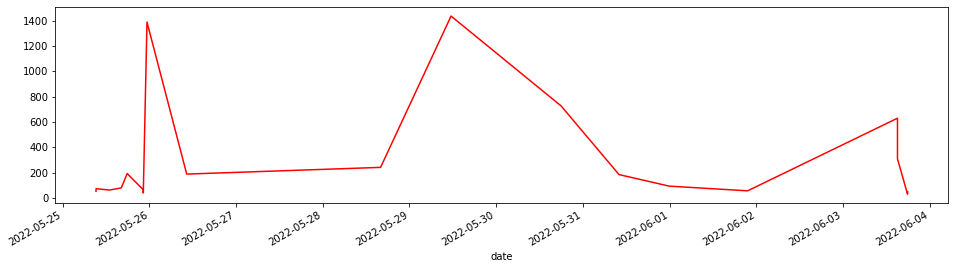

/tmp/ipykernel_20331/3739204534.py:159: MatplotlibDeprecationWarning: 
The 'quality' parameter of print_jpg() was deprecated in Matplotlib 3.3 and will be removed two minor releases later. Use pil_kwargs={'quality': ...} instead. If any parameter follows 'quality', they should be passed as keyword, not positionally.
  plt.savefig('VisualLikes.jpg',dpi=800, quality=90, optimize=True, progressive=True)
/tmp/ipykernel_20331/3739204534.py:159: MatplotlibDeprecationWarning: 
The 'optimize' parameter of print_jpg() was deprecated in Matplotlib 3.3 and will be removed two minor releases later. Use pil_kwargs={'optimize': ...} instead. If any parameter follows 'optimize', they should be passed as keyword, not positionally.
  plt.savefig('VisualLikes.jpg',dpi=800, quality=90, optimize=True, progressive=True)
/tmp/ipykernel_20331/3739204534.py:159: MatplotlibDeprecationWarning: 
The 'progressive' parameter of print_jpg() was deprecated in Matplotlib 3.3 and will be removed two minor releases lat

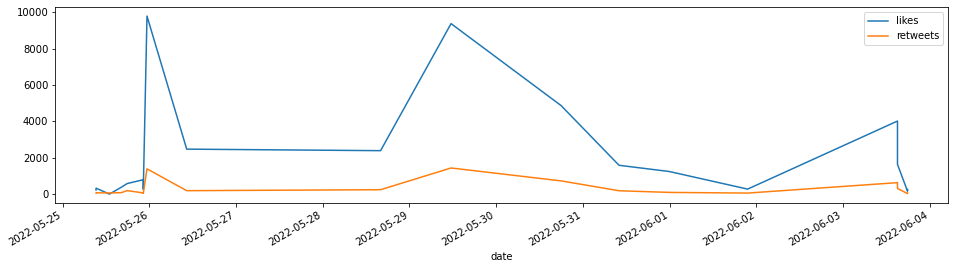

In [10]:
from tweepy import API 
from tweepy import Cursor
from tweepy.streaming import StreamListener
from tweepy import OAuthHandler
from tweepy import Stream
 
import twitter_credentials
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ACCESS_TOKEN ="1511746246494593032-u3t18TrXTsBT5SNqwh7yRNx1RW7AmA"
ACCESS_TOKEN_SECRET ="3JJzKQFI7O5lu2qs4ks4sQQn1ximGeKMYUPJg5sFgtpyb"
CONSUMER_KEY ="k8WtNYDfJt7D5WYX4KKQ2CqFM"
CONSUMER_SECRET ="wmz9QIFnpXQa7jsFmHypOb8koAygZvdWNbWDVKWBcx5WAnSAW2"
# # # # TWITTER CLIENT # # # #
class TwitterClient():
    def __init__(self, twitter_user=None):
        self.auth = TwitterAuthenticator().authenticate_twitter_app()
        self.twitter_client = API(self.auth)

        self.twitter_user = twitter_user

    def get_twitter_client_api(self):
        return self.twitter_client

    def get_user_timeline_tweets(self, num_tweets):
        tweets = []
        for tweet in Cursor(self.twitter_client.user_timeline, id=self.twitter_user).items(num_tweets):
            tweets.append(tweet)
        return tweets

    def get_friend_list(self, num_friends):
        friend_list = []
        for friend in Cursor(self.twitter_client.friends, id=self.twitter_user).items(num_friends):
            friend_list.append(friend)
        return friend_list

    def get_home_timeline_tweets(self, num_tweets):
        home_timeline_tweets = []
        for tweet in Cursor(self.twitter_client.home_timeline, id=self.twitter_user).items(num_tweets):
            home_timeline_tweets.append(tweet)
        return home_timeline_tweets


# # # # TWITTER AUTHENTICATER # # # #
class TwitterAuthenticator():

    def authenticate_twitter_app(self):
        auth = OAuthHandler(CONSUMER_KEY,CONSUMER_SECRET)
        auth.set_access_token(ACCESS_TOKEN, ACCESS_TOKEN_SECRET)
        return auth

# # # # TWITTER STREAMER # # # #
class TwitterStreamer():
    """
    Class for streaming and processing live tweets.
    """
    def __init__(self):
        self.twitter_autenticator = TwitterAuthenticator()    

    def stream_tweets(self, fetched_tweets_filename, hash_tag_list):
        # This handles Twitter authetification and the connection to Twitter Streaming API
        listener = TwitterListener(fetched_tweets_filename)
        auth = self.twitter_autenticator.authenticate_twitter_app() 
        stream = Stream(auth, listener)

        # This line filter Twitter Streams to capture data by the keywords: 
        stream.filter(track=hash_tag_list)


# # # # TWITTER STREAM LISTENER # # # #
class TwitterListener(StreamListener):
    """
    This is a basic listener that just prints received tweets to stdout.
    """
    def __init__(self, fetched_tweets_filename):
        self.fetched_tweets_filename = fetched_tweets_filename

    def on_data(self, data):
        try:
            print(data)
            with open(self.fetched_tweets_filename, 'a') as tf:
                tf.write(data)
            return True
        except BaseException as e:
            print("Error on_data %s" % str(e))
        return True
          
    def on_error(self, status):
        if status == 420:
            # Returning False on_data method in case rate limit occurs.
            return False
        print(status)


class TweetAnalyzer():
    """
    Functionality for analyzing and categorizing content from tweets.
    """
    def tweets_to_data_frame(self, tweets):
        df = pd.DataFrame(data=[tweet.text for tweet in tweets], columns=['tweets'])

        df['id'] = np.array([tweet.id for tweet in tweets])
        df['len'] = np.array([len(tweet.text) for tweet in tweets])
        df['date'] = np.array([tweet.created_at for tweet in tweets])
        df['source'] = np.array([tweet.source for tweet in tweets])
        df['likes'] = np.array([tweet.favorite_count for tweet in tweets])
        df['retweets'] = np.array([tweet.retweet_count for tweet in tweets])

        return df

if __name__ == '__main__':

    twitter_client = TwitterClient()
    tweet_analyzer = TweetAnalyzer()

    api = twitter_client.get_twitter_client_api()

    tweets = api.user_timeline(screen_name="@Macky_Sall", count=20)

    print(dir(tweets[0]))
    print(tweets[0].retweet_count)

    df = tweet_analyzer.tweets_to_data_frame(tweets)
    # enregistrer les donnees
    df.to_pickle('Macky.gzip') 
   # lire le fichier
    pd.read_pickle('Macky.gzip')
    # Get average length over all tweets:
    print(np.mean(df['len']))

    # Get the number of likes for the most liked tweet:
    print(np.max(df['likes']))

    # Get the number of retweets for the most retweeted tweet:
    print(np.max(df['retweets']))
    
    print(df.head(10))

    # Time Series
    #time_likes = pd.Series(data=df['len'].values, index=df['date'])
    #time_likes.plot(figsize=(16, 4), color='r')
    #plt.show()
    
    time_favs = pd.Series(data=df['likes'].values, index=df['date'])
    time_favs.plot(figsize=(16, 4), color='r')
    plt.show()
    plt.savefig('Visuallikes.jpg',dpi=800, quality=90, optimize=True, progressive=True) 
    
    time_retweets = pd.Series(data=df['retweets'].values, index=df['date'])
    time_retweets.plot(figsize=(16, 4), color='r')
    plt.savefig('Visualretweets.jpg',dpi=800, quality=90, optimize=True, progressive=True) 
    plt.show()

    # Layered Time Series:
    time_likes = pd.Series(data=df['likes'].values, index=df['date'])
    time_likes.plot(figsize=(16, 4), label="likes", legend=True)
    plt.savefig('VisualLikes.jpg',dpi=800, quality=90, optimize=True, progressive=True) 
    
    time_retweets = pd.Series(data=df['retweets'].values, index=df['date'])
    time_retweets.plot(figsize=(16, 4), label="retweets", legend=True)
    plt.savefig('VisualRetweets.jpg',dpi=800, quality=90, optimize=True, progressive=True) 
    plt.show()
    

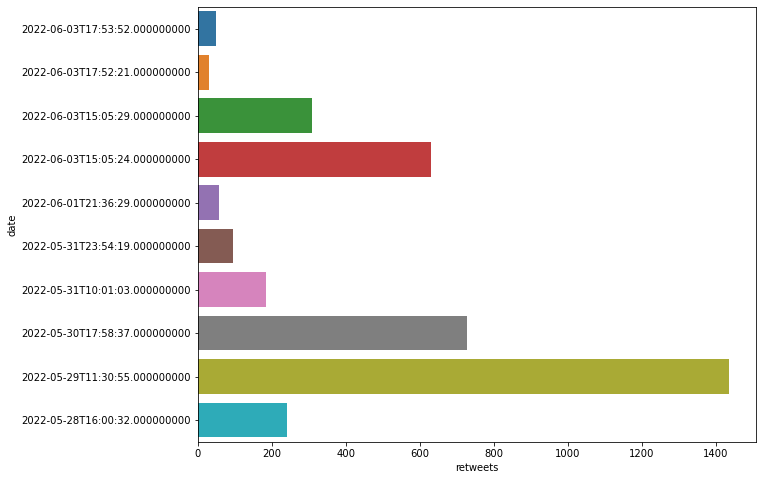

In [13]:
import seaborn as sns
plt.figure( figsize = ( 10, 8 ) )
sns.barplot( x="retweets", y="date", data=df.head(10))
plt.savefig('Visualbaretweets.jpg') 
plt.show()


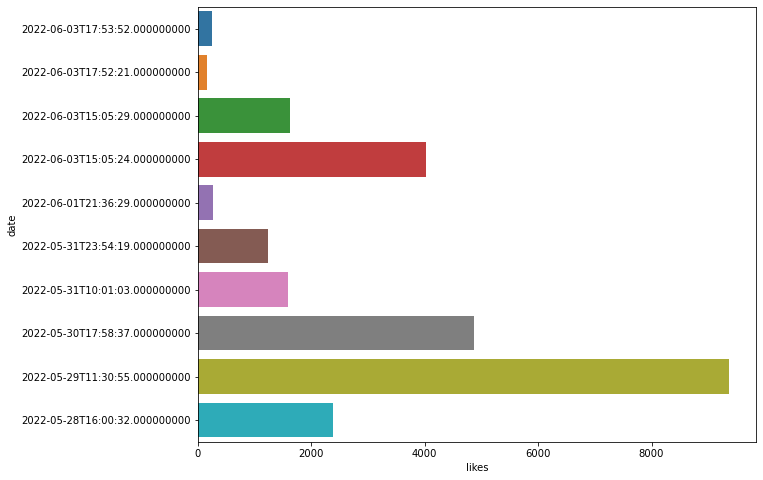

In [14]:
import seaborn as sns
plt.figure( figsize = ( 10, 8 ) )
sns.barplot( x="likes", y="date", data=df.head(10))
plt.savefig('Visualbarlikes.jpg') 
plt.show()
 

In [12]:
# lire le fichier
pd.read_pickle('Macky.gzip')

,tweets,id,len,date,source,likes,retweets
0,I would like to thank President #Putin for his...,1532782632764854272,130,2022-06-03 17:53:52,Twitter for iPhone,253,50
1,President #Putin expressed to us his readiness...,1532782254530994176,139,2022-06-03 17:52:21,Twitter for iPhone,160,31
2,Le Président #Poutine nous a exprimé sa dispon...,1532740261658431489,140,2022-06-03 15:05:29,Twitter for iPhone,1634,309
3,Je remercie le Président #Poutine pour son aim...,1532740240569516034,140,2022-06-03 15:05:24,Twitter for iPhone,4016,630
4,#ConseilDesMinistresSn https://t.co/X6WjbQcv5Z,1532113882017406977,46,2022-06-01 21:36:29,Twitter Web App,275,57
5,"Je remercie SEM Seyed Ibrahim Ra’isi, Pdt de l...",1531786181482012672,140,2022-05-31 23:54:19,Twitter for iPhone,1243,94
6,"Au nom de l’Union Africaine, je remercie les D...",1531576481498923009,140,2022-05-31 10:01:03,Twitter for iPhone,1584,185
7,Je remercie les Pdts Tshisekedi et Kagame pou...,1531334280516980737,140,2022-05-30 17:58:37,Twitter for iPhone,4866,727
8,Je suis gravement préoccupé par la montée de l...,1530874324084719617,139,2022-05-29 11:30:55,Twitter for iPhone,9371,1436
9,Je tiens à remercier mes chers homologues @Pau...,1530579786921390082,140,2022-05-28 16:00:32,Twitter for iPhone,2388,242
